# Recurrent Neural Net

In this notebook I will demonstrate how a Recurrent Neural Net (RNN) can be used to predict time series data very accurately.

### Import

As always we begin by importing all the required libraries.

In [1]:
%matplotlib inline

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
import os

In [2]:
csv_path = "./data/epidemic_process_raw_data.csv"
df = pd.read_csv(csv_path)
df.head(4)

,1,2,3,4,5,6,7,8,9,10,...,492,493,494,495,496,497,498,499,500,501
0,100.287149,103.541223,95.879814,96.354848,96.980932,97.855310,98.940537,100.187494,98.265709,95.307794,...,4.925236,4.922108,4.918981,4.915853,4.912726,4.950240,4.995291,5.040342,5.085393,5.130445
1,0.993774,1.017558,1.070030,1.116168,1.142078,1.134735,1.182418,1.272310,1.356565,1.438978,...,0.391775,0.384359,0.376942,0.369526,0.362109,0.356669,0.351595,0.346521,0.341447,0.336374
2,0.000000,0.017741,0.036585,0.054735,0.074266,0.096065,0.117691,0.139184,0.163615,0.189006,...,97.247764,96.062916,94.878068,93.693219,92.508371,92.617122,92.965783,93.314443,93.663103,94.011764
3,0.000000,0.000178,0.000364,0.000562,0.000757,0.000947,0.001160,0.001389,0.001635,0.001887,...,0.947347,0.950713,0.954079,0.957445,0.960811,0.959320,0.956929,0.954537,0.952146,0.949755


In [28]:

dfSusceptible = df[df.index % 4 == 0]
dfInfected = df[df.index % 4 == 1]
dfRecovered = df[df.index % 4 == 2]
dfDead = df[df.index % 4 == 3]
dfInfected.head()

,1,2,3,4,5,6,7,8,9,10,...,492,493,494,495,496,497,498,499,500,501
1,0.993774,1.017558,1.070030,1.116168,1.142078,1.134735,1.182418,1.272310,1.356565,1.438978,...,0.391775,0.384359,0.376942,0.369526,0.362109,0.356669,0.351595,0.346521,0.341447,0.336374
5,1.021677,1.045410,1.120324,1.175914,1.236878,1.306676,1.387931,1.477973,1.549873,1.615840,...,0.172933,0.171653,0.169739,0.167366,0.164993,0.162620,0.160247,0.157874,0.155501,0.153128
9,1.020043,1.011238,1.031122,1.048642,1.049479,1.022891,1.035862,1.079177,1.114531,1.147282,...,5.658505,5.625406,5.592308,5.559209,5.526111,5.493012,5.459914,5.426815,5.393717,5.360619
13,1.035248,1.014189,1.133178,1.135622,1.157984,1.213088,1.281406,1.359858,1.423234,1.481680,...,0.297238,0.292756,0.288433,0.284145,0.279857,0.275569,0.271280,0.266992,0.262704,0.258416
17,1.012666,1.016949,1.053194,1.097599,1.143640,1.192369,1.238880,1.283688,1.324305,1.363552,...,0.475822,0.467301,0.458779,0.450518,0.444609,0.438701,0.432715,0.425247,0.417780,0.410313


### Controll

We check three of the simulations to make sure the data seems correct.

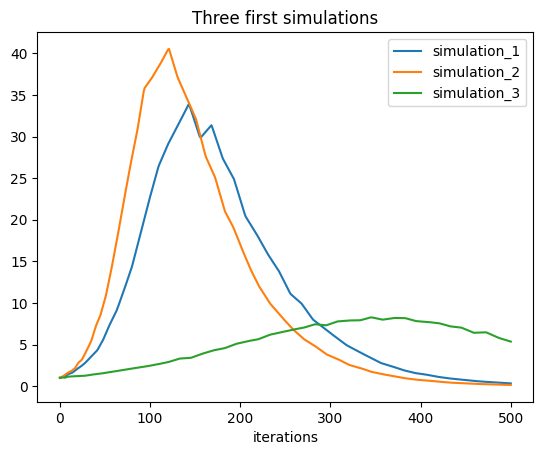

In [4]:
# Plot three of the simulations
fig, ax = plt.subplots()

ax.plot(range(dfInfected.shape[1]), dfInfected.loc[1,:], label="simulation_1")
ax.plot(range(dfInfected.shape[1]), dfInfected.loc[5,:], label="simulation_2")
ax.plot(range(dfInfected.shape[1]), dfInfected.loc[9,:], label="simulation_3")

ax.set_title("Three first simulations")
ax.set_xlabel("iterations")
ax.set_ylabel("")
ax.legend()

plt.show()

### Normalizing

We normalize and split the data to prepare it for training and testing.

In [5]:
dfInfected_arr = dfInfected.values
dfInfected_arr.shape
TRAIN_SPLIT = int(dfInfected_arr.shape[0]-dfInfected_arr.shape[0]*0.1)
print(TRAIN_SPLIT)

uni_train_mean = dfInfected_arr[:TRAIN_SPLIT].mean()
uni_train_std = dfInfected_arr[:TRAIN_SPLIT].std()
uni_data = (dfInfected_arr-uni_train_mean)/uni_train_std
print ('\nUnivariate data shape')
print(uni_data.shape)

135

Univariate data shape
(150, 501)


## Creating a TimeSeries

We now need to create a TimeSeries to use later on.

In [6]:
def time_series(dataset: np.ndarray, start_series: int, end_series: int, history_size: int = 20, target_size: int = 1) -> tuple[np.ndarray, np.ndarray]:
    '''
    Creates TimeSeries of sequential data to use with RNN training and predicting.
    
    Args:
        dataset: the data to create TimeSeries from
        start_series: index for the first entry
        end_series: index for the last entry
        history_size: number of past data to use in prediction
        target_size: amount of predictions to perform
    
    Returns:
        time_series, actual_values
    '''

    series = []
    actual_values = []

    start_index = history_size
    end_index = dataset.shape[1] - target_size

    for c in range(start_series, end_series):
        for i in range(start_index, end_index):
            indices = np.arange(i - history_size, i)
            series.append(dataset[c][indices].reshape((history_size, 1)))
            actual_values.append(dataset[c][i + target_size])
    
    return np.array(series), np.array(actual_values)


In [7]:
univariate_past_history = 20 # Days
univariate_future_target = 0 # Current day

x_train_uni, y_train_uni = time_series(uni_data, 0, TRAIN_SPLIT,
                                           univariate_past_history,
                                           univariate_future_target)
x_val_uni, y_val_uni = time_series(uni_data, TRAIN_SPLIT, len(uni_data),
                                       univariate_past_history,
                                       univariate_future_target)

In [8]:
print ('Single window of past history')
print (x_train_uni[0])
print ('\n Target number to predict')
print (y_train_uni[0])
print ('\n Number of traing data points')
print (y_train_uni.shape[0])
print ('\n Number of test data points')
print (x_val_uni.shape[0])

Single window of past history
[[-0.95291296]
 [-0.95044298]
 [-0.94499366]
 [-0.9402021 ]
 [-0.93751136]
 [-0.93827393]
 [-0.93332191]
 [-0.92398652]
 [-0.91523643]
 [-0.90667772]
 [-0.90243571]
 [-0.89846308]
 [-0.89449045]
 [-0.89051782]
 [-0.88593997]
 [-0.87701137]
 [-0.86808277]
 [-0.85915417]
 [-0.85022557]
 [-0.84167481]]

 Target number to predict
-0.8339932964893617

 Number of traing data points
64935

 Number of test data points
7215


In [9]:
def create_time_steps(length):
    return [i for i in range(-length, 0)]

def show_plot(plot_data: np.ndarray, delta: float, title: str):
    labels = ['History', 'True Future', 'Model Prediction']
    marker = ['.-', 'rx', 'go']
    time_steps = create_time_steps(plot_data[0].shape[0])

    fig, ax = plt.subplots()
    if delta:
        future = delta
    else:
        future = 0
    ax.set_title(title)
    for i, x in enumerate(plot_data):
        if i:
            ax.plot(future, plot_data[i], marker[i], markersize=10,label=labels[i])
        else:
            ax.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    ax.legend()
    ax.set_xlim([time_steps[0], (future+5)*2])
    ax.set_xlabel('Time-Step')
    return fig, ax

def show_dual_plot(plot_data1: np.ndarray, plot_data2: np.ndarray, delta: float, title1: str, title2: str):
    labels = ['History', 'True Future', 'Model Prediction']
    marker = ['.-', 'rx', 'go']
    time_steps1 = create_time_steps(plot_data1[0].shape[0])
    time_steps2 = create_time_steps(plot_data2[0].shape[0])

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    if delta:
        future = delta
    else:
        future = 0
    ax1.set_title(title1)
    ax2.set_title(title2)
    for i, x in enumerate(plot_data1):
        if i:
            ax1.plot(future, plot_data1[i], marker[i], markersize=10,label=labels[i])
        else:
            ax1.plot(time_steps1, plot_data1[i].flatten(), marker[i], label=labels[i])
    for i, x in enumerate(plot_data2):
        if i:
            ax2.plot(future, plot_data2[i], marker[i], markersize=10,label=labels[i])
        else:
            ax2.plot(time_steps2, plot_data2[i].flatten(), marker[i], label=labels[i])
    ax1.legend()
    ax2.legend()
    ax1.set_xlim([time_steps1[0], (future+5)*2])
    ax2.set_xlim([time_steps2[0], (future+5)*2])
    ax1.set_xlabel('Time-Step')
    ax2.set_xlabel('Time-Step')
    return fig, (ax1, ax2)

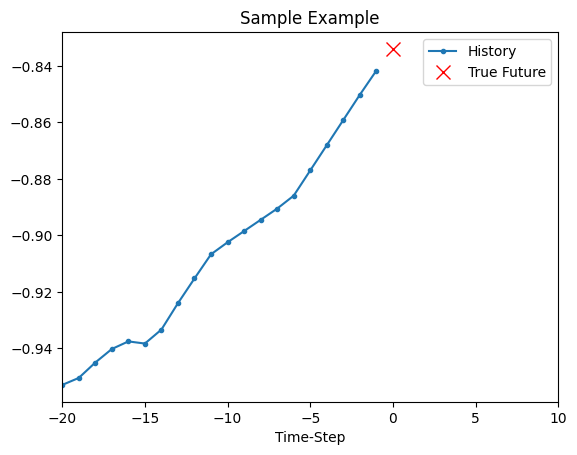

In [10]:
fig, ax = show_plot([x_train_uni[0], y_train_uni[0]], 0, 'Sample Example')
plt.show()

### Baseline Forecasting

To get a baseline we simply predict the mean of the history.

In [11]:

def baseline(history):
    return np.mean(history)

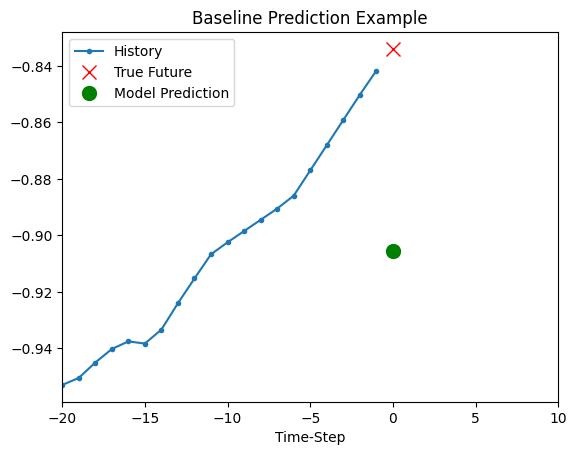

In [12]:
fig, ax = show_plot([x_train_uni[0], y_train_uni[0], baseline(x_train_uni[0])], 0, 'Baseline Prediction Example')
plt.show()

Not a very good guess in this case.

## Normalized LSTM based Forecasting

Now we implement a LSTM model and use it to predict the next value.

In [13]:
print (x_train_uni.shape)
print (y_train_uni.shape)
x_train_uni.dtype

(64935, 20, 1)
(64935,)


dtype('float64')

In [14]:
BATCH_SIZE = 256
BUFFER_SIZE = 10000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni))
val_univariate = val_univariate.batch(BATCH_SIZE).repeat()

print(train_univariate)

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 20, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>


## Initiating the simple LSTM model

2 layers with one having 8 neurons and one dense layer.

In [15]:
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='adam', loss='mae')
simple_lstm_model.summary()
print(x_train_uni.shape[-2:])

c:\Users\kalle\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

(20, 1)


In [16]:
for x, y in val_univariate.take(1):
    print(x.shape)
    print(simple_lstm_model.predict(x).shape)
    print(y.shape)

(256, 20, 1)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
(256, 1)
(256,)


### Training

In [17]:
EVALUATION_INTERVAL = 2000
EPOCHS = 10

simple_lstm_model.fit(train_univariate, 
                      epochs=EPOCHS,
                      steps_per_epoch=EVALUATION_INTERVAL,
                      validation_data=val_univariate, 
                      validation_steps=50)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1598 - val_loss: 0.0051
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0049 - val_loss: 0.0027
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 9/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 10/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0019 - val_loss: 0.0015


### Predicting

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


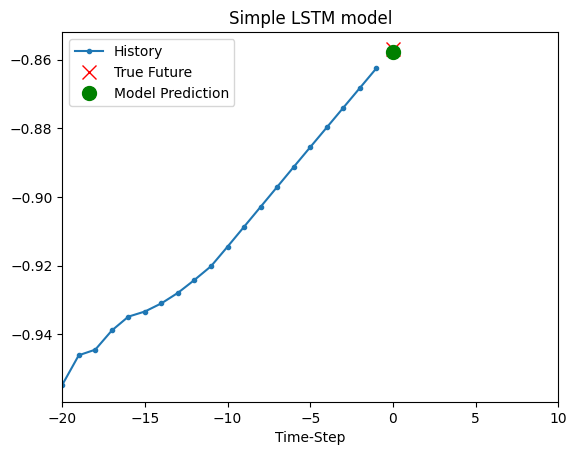

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


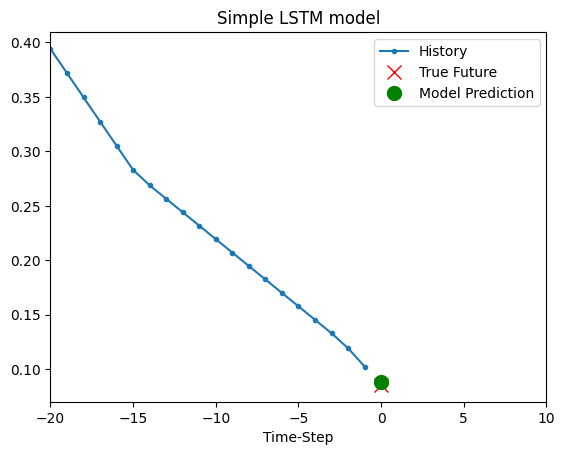

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


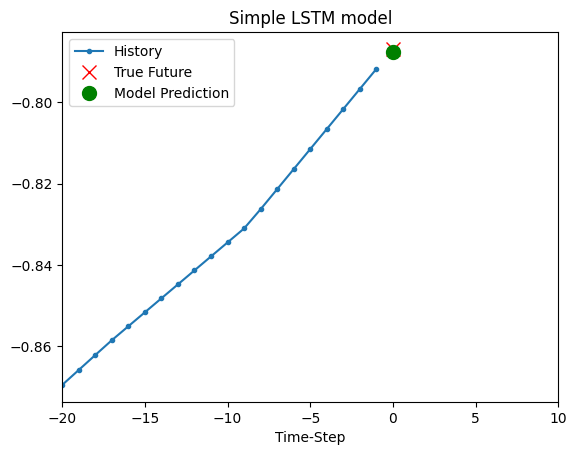

In [18]:
for x, y in val_univariate.take(3):
    fig, ax = show_plot([x[0].numpy(), y[0].numpy(), simple_lstm_model.predict(x)[0]], 0, 'Simple LSTM model')
    plt.show()

## Initiating one deeper and one wider LSTM model

4 layers with 3 having 16 -> 8 -> 4 neurons and one dense output.

The deeper model might be able to catch more complex patterns from the data while the wider one might be better suited since we don't have a lot of data.

In [19]:
deeper_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(16, return_sequences=True, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.LSTM(8, return_sequences=True),
    tf.keras.layers.LSTM(4),
    tf.keras.layers.Dense(1)
])

wider_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(32, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
])

deeper_lstm_model.compile(optimizer='adam', loss='mae')
deeper_lstm_model.summary()

wider_lstm_model.compile(optimizer='adam', loss='mae')
wider_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 20, 16)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 8)          │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 4)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,165 (8.46 KB)

 Trainable params: 2,165 (8.46 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
for x, y in val_univariate.take(1):
    print(x.shape)
    print(deeper_lstm_model.predict(x).shape)
    print(wider_lstm_model.predict(x).shape)
    print(y.shape)

(256, 20, 1)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
(256, 1)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
(256, 1)
(256,)


### Training

In [21]:
EVALUATION_INTERVAL_DEEPER = 1000
EVALUATION_INTERVAL_WIDER = 2000
EPOCHS = 10

deeper_lstm_model.fit(train_univariate, 
                      epochs=EPOCHS,
                      steps_per_epoch=EVALUATION_INTERVAL_DEEPER,
                      validation_data=val_univariate, 
                      validation_steps=50)

wider_lstm_model.fit(train_univariate, 
                      epochs=EPOCHS,
                      steps_per_epoch=EVALUATION_INTERVAL_WIDER,
                      validation_data=val_univariate, 
                      validation_steps=50)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1975 - val_loss: 0.0160
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0186 - val_loss: 0.0126
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0145 - val_loss: 0.0103
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0123 - val_loss: 0.0090
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0104 - val_loss: 0.0073
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0091 - val_loss: 0.0066
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0085 - val_loss: 0.0070
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0074 - val_loss: 0.0082
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0070 - val_loss: 0.0077
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0068 - val_loss: 0.0053
Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0768 - val_loss: 0.0070
Epoch 2/10
2000/2000 ━━━━━━━━

### Predicting

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


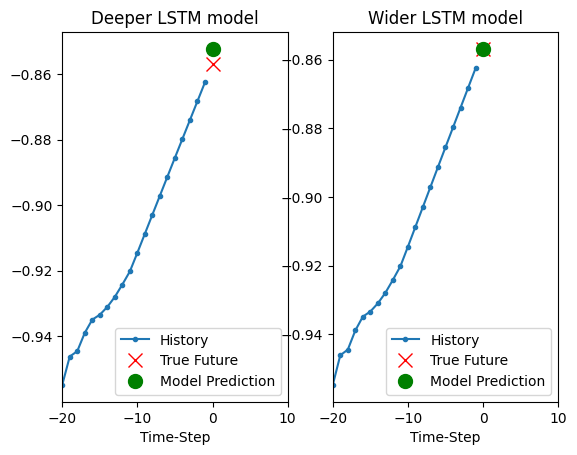

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


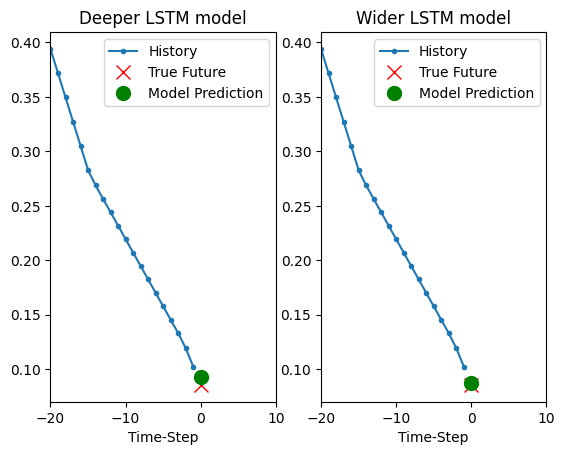

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


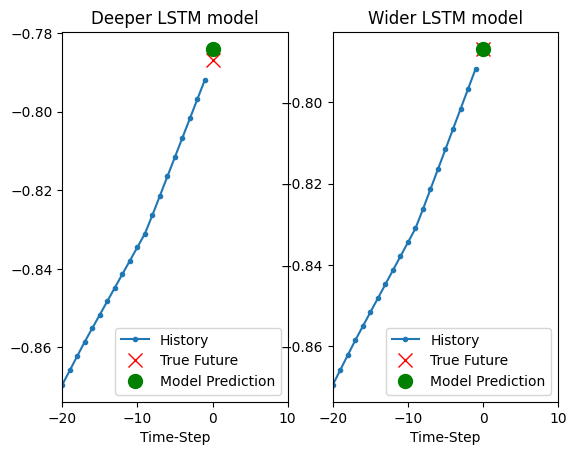

In [22]:
for x, y in val_univariate.take(3):
    fig, (ax1, ax2) = show_dual_plot([x[0].numpy(),
                                      y[0].numpy(),
                                      deeper_lstm_model.predict(x)[0]],
                                      [x[0].numpy(),
                                       y[0].numpy(),
                                       wider_lstm_model.predict(x)[0]],
                                      0,
                                      'Deeper LSTM model',
                                      'Wider LSTM model')
    plt.show()

### Findings

It turns out that the deeper model might have either overfit on the data or that the gradients vanished along the training since validation loss stagnated around epoch 4.

The wider model on the other hand was seemingly worse until epoch 10 when it passed the simple model in validation loss and hit the predictions almost spot on.

## Multivariate LSTM based forecasting - Single Step

This time we will be using three inputs instead to predict the number of infected people. (infected, recovered, deceased)

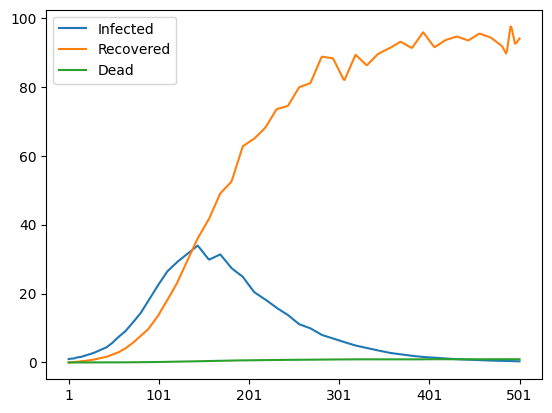

In [29]:
dfInfected.loc[1,:].plot(label='Infected')
dfRecovered.loc[2,:].plot(label='Recovered')
dfDead.loc[3,:].plot(label='Dead')
dfInfected_arr = dfInfected.values
dfRecovered_arr = dfRecovered.values
dfDead_arr = dfDead.values
plt.legend()
plt.show()

## Preparing data

In [31]:
dfInfected_train_mean = dfInfected_arr[:TRAIN_SPLIT].mean()
dfInfected_train_std = dfInfected_arr[:TRAIN_SPLIT].std()
dfInfected_data = (dfInfected_arr-dfInfected_train_mean)/dfInfected_train_std
#for Recovered
dfRecovered_train_mean = dfRecovered_arr[:TRAIN_SPLIT].mean()
dfRecovered_train_std = dfRecovered_arr[:TRAIN_SPLIT].std()
dfRecovered_data = (dfRecovered_arr-dfRecovered_train_mean)/dfRecovered_train_std
#for Dead
dfDead_train_mean = dfDead_arr[:TRAIN_SPLIT].mean()
dfDead_train_std = dfDead_arr[:TRAIN_SPLIT].std()
dfDead_data = (dfDead_arr-dfDead_train_mean)/dfDead_train_std

In [32]:
dataset = np.array([dfInfected_data, dfRecovered_data, dfDead_data])
dataset.shape
print ('\n Multivariate data shape')
print(dataset.shape)


 Multivariate data shape
(3, 150, 501)


## Creating multivariate TimeSeries

In [33]:
def multivariate_time_series(dataset: np.ndarray, target: np.ndarray, start_series: int, end_series: int, history_size: int = 20, target_size: int = 1, step: int = 2, single_step: bool = False) -> tuple[np.ndarray, np.ndarray]:
    '''
    Creates multivariate TimeSeries of sequential data to use with RNN training and predicting.
    
    Args:
        dataset: data to create TimeSeries from
        target: data to predict
        start_series: index for the first entry
        end_series: index for the last entry
        history_size: number of past data to use in prediction
        target_size: amount of predictions to perform
        step: how large of a step to take
        single_step: take one step or not
    
    Returns:
        time_series, actual_values
    '''

    data = []
    labels = []
    start_index = history_size
    end_index = len(dataset[0][0]) - target_size   
    for c in range(start_series, end_series):
        for i in range(start_index, end_index):
            indices = range(i-history_size, i, step)
            one = dataset[0][c][indices]
            two = dataset[1][c][indices]
            three = dataset[2][c][indices]
            data.append(np.transpose(np.array([one, two, three])))
            
            if single_step:
                labels.append(target[c][i+target_size])
            else:
                labels.append(np.transpose(target[c][i:i+target_size]))
    return np.array(data), np.array(labels)


In [34]:
past_history = 20
future_target = 5
STEP = 2

x_train_single, y_train_single = multivariate_time_series(dataset, dfInfected_data, 0, TRAIN_SPLIT, 
                                                   past_history, future_target, STEP,
                                                   single_step=True)
x_val_single, y_val_single = multivariate_time_series(dataset, dfInfected_data, TRAIN_SPLIT, dataset.shape[1], 
                                               past_history, future_target, STEP,
                                               single_step=True)

In [35]:
print ('Single window of past history : {}'.format(x_train_single[0].shape))
print(dataset.shape)

Single window of past history : (10, 3)
(3, 150, 501)


In [36]:
train_data_single = tf.data.Dataset.from_tensor_slices((x_train_single, y_train_single))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((x_val_single, y_val_single))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

### Plotting tools

In [41]:
def plot_train_history(history, title):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_dual_train_history(history1, history2, title1, title2):
    loss1 = history1.history['loss']
    loss2 = history2.history['loss']
    val_loss1 = history1.history['val_loss']
    val_loss2 = history2.history['val_loss']
    epochs1 = range(len(loss1))
    epochs2 = range(len(loss2))
    plt.figure()
    plt.subplot(1, 2, 1)
    plt.plot(epochs1, loss1, 'b', label='Training loss')
    plt.plot(epochs1, val_loss1, 'r', label='Validation loss')
    plt.title(title1)
    plt.legend()
    plt.subplot(1, 2, 1)
    plt.plot(epochs2, loss2, 'b', label='Training loss')
    plt.plot(epochs2, val_loss2, 'r', label='Validation loss')
    plt.title(title1)
    plt.legend()
    plt.show()

## Initiating the simple model

This time we use the wide layout for the simple model.

In [37]:
single_step_model = tf.keras.models.Sequential()
single_step_model.add(tf.keras.layers.LSTM(32, input_shape=x_train_single.shape[-2:]))
single_step_model.add(tf.keras.layers.Dense(1))

single_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(), loss='mae')
single_step_model.summary()
x_train_single.shape[-2:]

c:\Users\kalle\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

(10, 3)

In [38]:
for x, y in val_data_single.take(1):
    print(single_step_model.predict(x).shape)
print ('\n Number of traing data points')
print (x_train_single.shape[0])
print ('\n Number of test data points')
print (x_val_single.shape[0])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
(256, 1)

 Number of traing data points
64260

 Number of test data points
7140


### Training

In [39]:
single_step_history = single_step_model.fit(train_data_single, epochs=EPOCHS,
                                            steps_per_epoch=EVALUATION_INTERVAL,
                                            validation_data=val_data_single,
                                            validation_steps=50)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0757 - val_loss: 0.0294
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0274 - val_loss: 0.0278
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0230 - val_loss: 0.0200
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0204 - val_loss: 0.0162
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0188 - val_loss: 0.0151
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0176 - val_loss: 0.0164
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0169 - val_loss: 0.0139
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0141
Epoch 9/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0157 - val_loss: 0.0133
Epoch 10/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0153 - val_loss: 0.0131


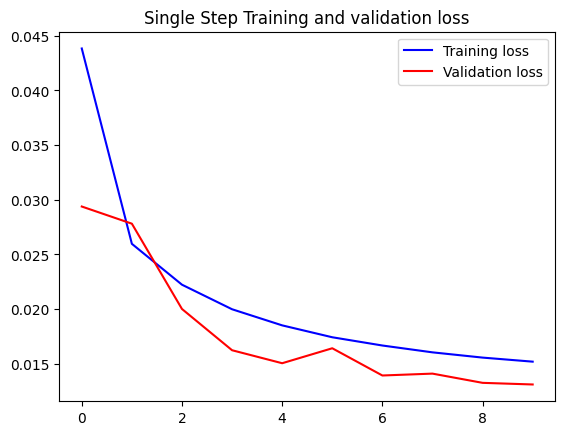

In [42]:
plot_train_history(single_step_history,'Single Step Training and validation loss')

### predicting

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


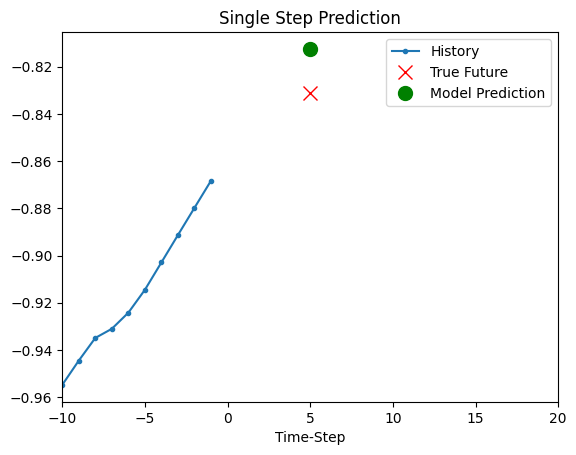

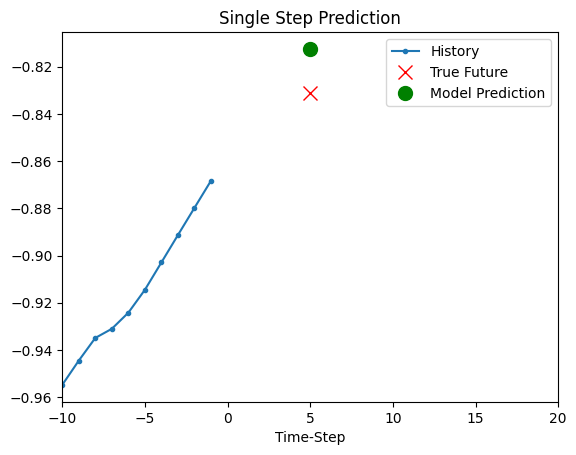

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


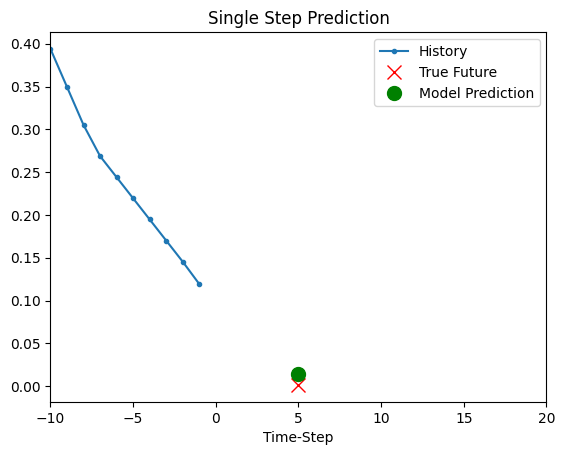

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


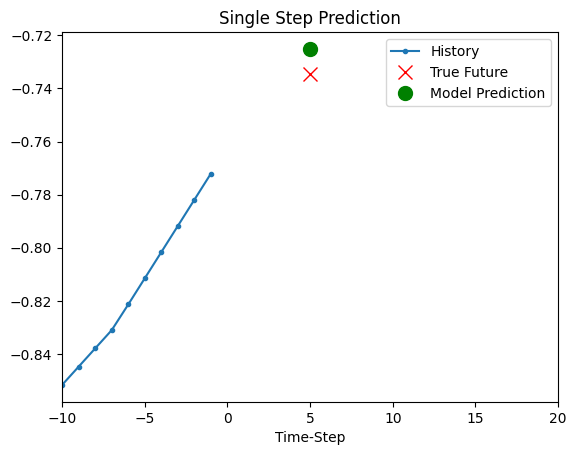

In [44]:
for x, y in val_data_single.take(3):
    fig, ax = show_plot([x[0][:, 0].numpy(), y[0].numpy(),
                    single_step_model.predict(x)[0]], future_target,
                   'Single Step Prediction')
    plt.show()